In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
import ast 

## 1ere section : analyse du dataset (arxiv)

à l'issue de ce notebook nous aurons l'occasion de parcourir ce dataset, de traiter l'étendu des données le constituant (données textuelles précisèment), les transformer et appliquer un problème de ML dessus

le dataset : arXiv paper abstract dataset for building multi-label text classifiers. // https://www.kaggle.com/datasets/spsayakpaul/arxiv-paper-abstracts/data 


In [5]:
def charger_dataset(chemin_dataset : str = "./data/arxiv_data.csv"):
    #chemin par défaut renvoie au dataset avec abstract 
    return pd.read_csv(chemin_dataset)

df = charger_dataset()
df.describe()

,titles,summaries,terms
count,51774,51774,51774
unique,38972,38979,3157
top,Transformers in Vision: A Survey,Astounding results from Transformer models on ...,['cs.CV']
freq,7,7,17369


### Analyse des données du dataset 

Nombre total de documents : 51774
Colonnes disponibles : ['titles', 'summaries', 'terms']
Valeurs manquantes par colonne :
titles       0
summaries    0
terms        0
dtype: int64
Nombre de catégories uniques : 3157
Distribution des catégories (top 10) :
terms
['cs.CV']                        17369
['cs.LG', 'stat.ML']              5251
['cs.LG']                         2732
['cs.CV', 'cs.LG']                2067
['cs.LG', 'cs.AI']                1702
['cs.LG', 'cs.AI', 'stat.ML']     1470
['stat.ML', 'cs.LG']              1376
['cs.CV', 'cs.AI']                 939
['cs.CV', 'cs.LG', 'eess.IV']      855
['cs.CV', 'eess.IV']               769
Name: count, dtype: int64
nombre réel de catégories unique :  1099  => catégories : 
  {'I.2.6; I.4.6; I.5.5', 'I.2.0; I.5.0', 'cs.IR', 'physics.ao-ph', 'I.2, I.4', 'I.4.6; G.3', 'I.2.11', 'H.1.1; H.3.3; G.3; I.1.2; I.2.6; I.4.2; I.5.3; E.4', '68U35', 'I.6.4; I.5.3; I.4.6; I.2.4', 'I.2.9', '93E20, 93E35, 60J20', '62F35, 65K10', 'Primary 62J10, 62

Text(0, 0.5, 'Nombre de documents')

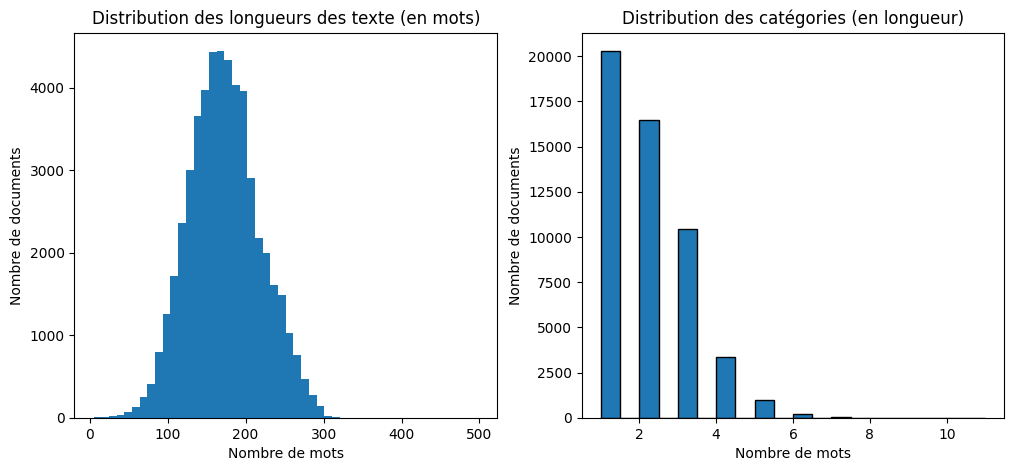

In [6]:
num_documents = df.shape[0]
print(f"Nombre total de documents : {num_documents}")

colonnes = df.columns.tolist()
print(f"Colonnes disponibles : {colonnes}")

valeurs_manquantes = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(valeurs_manquantes)

colonne_categories = 'terms'  
colonnes_texte = 'summaries'  

### Region 1 : analyse des catégories : terms 


num_categories = df[colonne_categories].nunique()
print(f"Nombre de catégories uniques : {num_categories}")

distribution_categories = df[colonne_categories].value_counts()
print("Distribution des catégories (top 10) :")
print(distribution_categories.head(10))



ensemble_categories = set()
for categories_str in df[colonne_categories]:
    #convertir la chaine et liste 
    categories_list = ast.literal_eval(categories_str) 
    ensemble_categories.update(categories_list)
        

print("nombre réel de catégories unique : ",len(ensemble_categories)," => catégories : \n ",ensemble_categories)

df["longueur_categories"] = df[colonne_categories].apply(lambda x : len(ast.literal_eval(x)))
moyenne_labels_par_doc = df["longueur_categories"].mean()
max_labels_par_doc = df["longueur_categories"].max()
print(f"Nombre moyen de labels par document : {moyenne_labels_par_doc}")
print(f"Nombre maximum de labels par document : {max_labels_par_doc}")


## 2 : analyse de la colonne texte  

df["longueur_texte"] = df[colonnes_texte].astype(str).str.split().apply(len)
longueur_moyenne = df["longueur_texte"].mean()
longueur_mediane = df["longueur_texte"].median()
longueur_min = df["longueur_texte"].min()
longueur_max = df["longueur_texte"].max()
print(f"Longueur moyenne des abstracts (mots) : {longueur_moyenne}")
print(f"Longueur médiane des abstracts (mots) : {longueur_mediane}")
print(f"Longueur minimale : {longueur_min}, maximale : {longueur_max}")
 
 
fig, graphiques = plt.subplots(1, 2, figsize=(12, 5))
graphiques[0].hist(df["longueur_texte"], bins=50)
graphiques[0].set_title('Distribution des longueurs des texte (en mots)')
graphiques[0].set_xlabel('Nombre de mots')
graphiques[0].set_ylabel('Nombre de documents')

graphiques[1].hist(df["longueur_categories"], bins=20, edgecolor='black')
graphiques[1].set_title('Distribution des catégories (en longueur)')
graphiques[1].set_xlabel('Nombre de mots')
graphiques[1].set_ylabel('Nombre de documents')

première analyse à chaud : difficultés quant au nombre de catégories distinctes 1099 => à voir si on en garde que les top-k plus fréquentes ? 

MultiLabelClassification ? avec seuillage sur une sigmoide à la fin (ou garder softmax sur une seule sortie seuleemnt parmi plusieurs labels ???) 

Stratégie : oneVsRest/ All , classe CS et le reste .... et ensuite physique et le reste (y compris CS ...) ??? wrapper autour d'un classifier offert par scikit 
mais on traite pas les similarités entre catégories ??? car nous supposons que les labels sont indépendants, optimisation en ajoutant les prédictions dans les features si jamais ??? à explorer le classifierChain ? 
p(X)=ML , seconde préd P(X+ML)= CV ? 



## 2. Traitement et Transformation du Texte

Dans cette section, nous allons explorer les techniques de traitement du texte en utilisant scikit-learn, en suivant le tutoriel officiel : https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html#tutorial-setup

Nous allons appliquer ces techniques sur notre dataset arXiv pour extraire des caractéristiques numériques des textes.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mokht\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mokht\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mokht\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mokht\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### A. Extraction de caractéristiques à partir de fichiers texte - Sacs de mots (Bags of Words)

Le moyen le plus intuitif de transformer le texte en vecteur est d'utiliser une représentation en sacs de mots :

1. Attribuer un identifiant entier fixe à chaque mot apparaissant dans n'importe quel document de l'ensemble d'entraînement (par exemple en construisant un dictionnaire de mots vers indices entiers).
2. Pour chaque document #i, compter le nombre d'occurrences de chaque mot w et le stocker dans X[i, j] comme valeur de la caractéristique #j où j est l'index du mot w dans le dictionnaire.

Cette approche ignore l'ordre des mots et se concentre uniquement sur leur fréquence.

In [8]:
MAX_FEATURES = 5000 ; MIN_DF = 100 ; MAX_DF = 0.8
configuration_vectorizer = {"max_features":MAX_FEATURES,"stop_words":"english","min_df":MIN_DF,"max_df":MAX_DF,"lowercase":True}
count_vectorizer = CountVectorizer(**configuration_vectorizer)

print("\n--- Lancement du vectorizer sur dataset arxiv (summariess) ---")
summaries_liste = df['summaries'].tolist()

X_arxiv_summaries = count_vectorizer.fit_transform(summaries_liste)
print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
print("matrice finale forme:", X_arxiv_summaries.shape)
print("Exemple de caractéristiques pour le premier document:")




--- Lancement du vectorizer sur dataset arxiv (summariess) ---
Vocabulaire taille finale du dataset: 4190
matrice finale forme: (51774, 4190)
Exemple de caractéristiques pour le premier document:


### Remarque : 
avec une configuration de base injectée dans le vectorizer : on se retrouve avec un vocabulaire de 12368

min_df = 10 : nombre occurence minimal des mots est de 10 dans tout le corpus 
max_df 0.8 : si trop fréquent alors dans ce cas on se retrouve avec des mots trop fréquents dans ce cas alors on dévide de pas traiter ces mots ( comme paper ....)

### C. Prétraitement avec Lemmatisation, Stemmatisation et autres techniques

Le prétraitement avancé du texte va au-delà de la simple tokenisation et du filtrage des mots vides. Nous allons explorer plusieurs techniques importantes :

stemming lemmatisation, etc ... puis comme résultat final on va faire notre fonction de prétraitement, et comparer taille de la matrice à la fin du vectorizer dans les deux cas avec la même configuration. 

In [9]:
import re
from typing import Literal


def preprocess_texte(texte:str,strategie:Literal["stemmer","lemmatizer"]="lemmatizer") -> str:
    texte = texte.lower().strip()
    texte = re.sub(r'[^\w\s]', '', texte)#gardons seulement lettre chiffre et espace
    tokens = word_tokenize(texte) #premiere tokenization
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words and len(token)>=2 and not token.isdigit()]
    if strategie == "stemmer":
        stemmer_objet = PorterStemmer()
        liste_tokens_propres =  [stemmer_objet.stem(token) for token in tokens]
    elif strategie == "lemmatizer":
        lemmatizer_objet = WordNetLemmatizer()
        liste_tokens_propres =  [lemmatizer_objet.lemmatize(token) for token in tokens]
    else  :
        raise NotImplementedError("pas d'implémentation sur autre approchess")
        liste_tokens_propres = []
    
    if liste_tokens_propres is not None : 
        return " ".join(liste_tokens_propres)
    

#test de la méthode 

texte_random = "there is nothing that can handle this paper i can't even imagine"
texte_cleaned = preprocess_texte(texte_random)
print("texte_cleand : " , texte_cleaned)


# df["summaries_nettoye"]= df["summaries"].apply(preprocess_texte)

texte_cleand :  nothing handle paper cant even imagine


In [10]:
""" application du vectorizer directement """
df["summaries_nettoye"]=df["summaries"].apply(preprocess_texte)
summaries_cleaned_liste = df["summaries_nettoye"].tolist()
X_arxiv_summaries_nettoye = count_vectorizer.fit_transform(summaries_cleaned_liste)
print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
print("Exemple de caractéristiques pour le premier document:")

Vocabulaire taille finale du dataset: 3669
matrice finale forme: (51774, 3669)
Exemple de caractéristiques pour le premier document:


### Observation : 
pas de changement majeur sur la taille du vocabulaire .... 

In [11]:
tfidf_vectorizer = TfidfVectorizer(**configuration_vectorizer)

def vectorizer_simple(liste : str , vectorizer_type:Literal["countVectorizer","tfidfVectorizer"]="countVectorizer"): 
    if vectorizer_type == "countVectorizer" : 
        X_arxiv_summaries_nettoye = count_vectorizer.fit_transform(liste)
        print("Vocabulaire taille finale du dataset:", len(count_vectorizer.get_feature_names_out()))
        print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
    elif vectorizer_type == "tfidfVectorizer" : 
        X_arxiv_summaries_nettoye = tfidf_vectorizer.fit_transform(liste)
        vocabulaire = tfidf_vectorizer.get_feature_names_out()
        idf_scores = tfidf_vectorizer.idf_
        top_terms = sorted(zip(vocabulaire, idf_scores), key=lambda x: x[1], reverse=True)[:10]
        print("-- affichage des termes -- :")
        for term, idf in top_terms:
            print(f"    {term}: {idf}")
        print("matrice finale forme:", X_arxiv_summaries_nettoye.shape)
        X_arxiv_summaries_nettoye = normalize(X_arxiv_summaries_nettoye, norm='l2')
    return X_arxiv_summaries_nettoye

PHRASES_DOCUMENT_NETTOYEES = df["summaries_nettoye"].tolist()

liste_vectorizer_tf_idf = vectorizer_simple(PHRASES_DOCUMENT_NETTOYEES,"tfidfVectorizer")

-- affichage des termes -- :
    adaption: 7.239542169422526
    adjusted: 7.239542169422526
    dirichlet: 7.239542169422526
    gridworld: 7.239542169422526
    mechanical: 7.239542169422526
    misleading: 7.239542169422526
    motor: 7.239542169422526
    nonstationarity: 7.239542169422526
    onedimensional: 7.239542169422526
    origin: 7.239542169422526
matrice finale forme: (51774, 3669)


### Entrainement doc2Vec

Documentation de l'api : https://radimrehurek.com/gensim/models/doc2vec.html

hypothèse : on traite les summaries ici comme des documents et la finalité ce sera donc de comparer directement l'approche avec du word2Vec , Glove et les sentenceTransformers ...

In [46]:
from gensim.models.doc2vec import Doc2Vec , TaggedDocument
from gensim.test.utils import get_tmpfile #pour poursuivre entrainement sur modèle loaded 

import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)



documents_tagges = [TaggedDocument(doc.split(),[f"doc_{i}"]) for i,doc in enumerate(PHRASES_DOCUMENT_NETTOYEES)]

doc2vec_conf = {"vector_size":300,"window":5,"min_count":5,"workers":8,"dm":1,"epochs":40}

doc2vec_modele = Doc2Vec(**doc2vec_conf)#pv-dm en mettant  = 1

doc2vec_modele.build_vocab(documents_tagges) #prépare modele pour entrainement , word frequency ...
print(f"vocabulaire : {len(doc2vec_modele.wv)} mots")

doc2vec_modele.train(documents_tagges, total_examples=doc2vec_modele.corpus_count, epochs=doc2vec_modele.epochs)


2026-04-09 21:50:49,418 : INFO : Doc2Vec lifecycle event {'params': 'Doc2Vec<dm/m,d300,n5,w5,mc5,s0.001,t8>', 'datetime': '2026-04-09T21:50:49.418554', 'gensim': '4.4.0', 'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
2026-04-09 21:50:49,419 : INFO : collecting all words and their counts
2026-04-09 21:50:49,419 : INFO : PROGRESS: at example #0, processed 0 words (0 words/s), 0 word types, 0 tags
2026-04-09 21:50:49,566 : INFO : PROGRESS: at example #10000, processed 1102596 words (7498449 words/s), 34907 word types, 10000 tags
2026-04-09 21:50:49,735 : INFO : PROGRESS: at example #20000, processed 2198907 words (6529022 words/s), 50571 word types, 20000 tags
2026-04-09 21:50:49,928 : INFO : PROGRESS: at example #30000, processed 3295654 words (5747306 words/s), 64857 word types, 30000 tags
2026-04-09 21:50:50,102 : INFO : PROGRESS: at example #40000, processed 4365166 words (6131

vocabulaire : 24674 mots


2026-04-09 21:50:54,243 : INFO : EPOCH 0 - PROGRESS: at 16.07% examples, 826545 words/s, in_qsize 15, out_qsize 0
2026-04-09 21:50:55,243 : INFO : EPOCH 0 - PROGRESS: at 32.37% examples, 839161 words/s, in_qsize 15, out_qsize 0
2026-04-09 21:50:56,258 : INFO : EPOCH 0 - PROGRESS: at 50.42% examples, 866467 words/s, in_qsize 15, out_qsize 0
2026-04-09 21:50:57,264 : INFO : EPOCH 0 - PROGRESS: at 69.98% examples, 893257 words/s, in_qsize 15, out_qsize 0
2026-04-09 21:50:58,271 : INFO : EPOCH 0 - PROGRESS: at 87.82% examples, 901834 words/s, in_qsize 16, out_qsize 0
2026-04-09 21:50:58,873 : INFO : EPOCH 0: training on 5645342 raw words (5156760 effective words) took 5.6s, 915300 effective words/s
2026-04-09 21:50:59,920 : INFO : EPOCH 1 - PROGRESS: at 14.12% examples, 695072 words/s, in_qsize 15, out_qsize 0
2026-04-09 21:51:00,941 : INFO : EPOCH 1 - PROGRESS: at 24.64% examples, 621661 words/s, in_qsize 15, out_qsize 0
2026-04-09 21:51:01,965 : INFO : EPOCH 1 - PROGRESS: at 34.68% examp

In [ ]:

documents_embeddings = [doc2vec_modele.dv[f'doc_{i}'] for i in range(len(PHRASES_DOCUMENT_NETTOYEES))]
X_doc2vec = np.array(documents_embeddings)

print(f"Shape Doc2Vec: {X_doc2vec.shape}")

Shape Doc2Vec: (51774, 300)


### chargement du modèle ou persistence
on persiste embeddings ici 


In [51]:
np.save(f"models/embeddings_doc2vec_{doc2vec_modele.vector_size}.npy", X_doc2vec)
# X_doc2vec_charge = np.load("embeddings_doc2vec.npy")



### test similarités nouveau modele

In [53]:

def inference_nouveau_document(doc: str , top_n = 5):
    tokens = preprocess_texte(doc).split()
    nouveau_vec = doc2vec_modele.infer_vector(tokens)
    print("nouveau vec : ",nouveau_vec)
    similaires_inferes = doc2vec_modele.dv.most_similar([nouveau_vec], topn=top_n)
    print("Documents similaires au nouveau texte :")
    for doc_id, sim in similaires_inferes:
        print(f"{doc_id}: {sim:.3f}")

inference_nouveau_document("deep neural networks are good architectures")

nouveau vec :  [ 1.03363752e-01 -1.20757677e-01 -9.60743800e-03  6.37001619e-02
  2.33183429e-01 -2.39176437e-01  9.62799191e-02  7.09233508e-02
 -4.02615815e-01  1.80006176e-01 -2.42746070e-01  1.17498241e-01
 -2.73925569e-02  1.99723765e-01 -5.05787879e-02 -2.02784866e-01
 -2.94899698e-02 -1.04222946e-01  1.09348610e-01 -1.27874583e-01
 -8.65983963e-02 -5.74646704e-02 -5.68403006e-02 -3.10544729e-01
  9.16231498e-02 -1.70374796e-01 -4.34544563e-01 -1.90523103e-01
 -2.08260804e-01 -2.19744310e-01 -1.66724786e-01  2.52194945e-02
 -2.43145943e-01 -1.26045659e-01 -1.79388039e-02  3.08618367e-01
  2.34438539e-01  1.53476521e-01 -2.09008902e-01 -3.30008894e-01
  1.15764223e-01 -1.12255188e-02 -1.84849761e-02  1.21995911e-01
  6.60663843e-02 -3.26372730e-03 -4.92100894e-01 -1.96483701e-01
 -9.61572602e-02 -1.75637100e-02 -3.12225461e-01  2.70999670e-02
  2.20115334e-02  1.98256239e-01 -1.39402136e-01  1.04168594e-01
 -5.02997153e-02  2.33623362e-03  2.20415577e-01  1.89336330e-01
  2.614153